In [5]:
# 🔧 Configuración del notebook
import warnings
warnings.filterwarnings('ignore')

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import os


# --- Configura aquí la ruta según tu entorno ---
ARCHIVO = 'datos_procesados.csv'

# Intenta cargar desde distintas ubicaciones comunes
rutas = [
    ARCHIVO,                                          # directorio actual
    f'/content/{ARCHIVO}',                            # Colab raíz
    f'/content/drive/MyDrive/{ARCHIVO}',              # Google Drive
    f'../data/{ARCHIVO}',                             # carpeta data relativa
]

df = None
for ruta in rutas:
    if os.path.exists(ruta):
        df = pd.read_csv(ruta)
        print(f"✅ Archivo cargado desde: {ruta}")
        break

if df is None:
    raise FileNotFoundError(
        f"❌ No se encontró '{ARCHIVO}'. "
        "Sube el archivo al entorno o ajusta la ruta."
    )

✅ Archivo cargado desde: /content/drive/MyDrive/datos_procesados.csv


Verificamos si los clusters existen:

#Detectamos Outliers utilizando Isolation Forest

In [8]:
# ============================================
# 🌲 DETECCIÓN DE OUTLIERS - ISOLATION FOREST
# ============================================
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# --- 1. Preparamos los features  ---
# --- Se excluyen las columnas de cluster y POBREZA ---
cols_excluir = ['POBREZA']
feature_cols = [col for col in df.select_dtypes(include=[np.number]).columns
                if col not in cols_excluir]

print(f"📌 Variables usadas para Isolation Forest: {feature_cols}")

X = df[feature_cols].copy()

# --- 2. Escalar No es obligatorio, pero mejora consistencia ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 3. Aplicar Isolation Forest ---
iso_forest = IsolationForest(
    n_estimators=100,      # número de árboles
    contamination=0.05,    # % esperado de outliers
    random_state=42
)

df['outlier_iforest'] = iso_forest.fit_predict(X_scaled)
# Resultado: -1 = outlier, 1 = normal

df['outlier_score']   = iso_forest.decision_function(X_scaled)

# Convertir a etiqueta más legible
df['es_outlier'] = df['outlier_iforest'].map({-1: 'Outlier', 1: 'Normal'})

# --- 4. Resumen ---
n_outliers = (df['outlier_iforest'] == -1).sum()
n_total = len(df)
print(f"\n📊 Outliers detectados: {n_outliers} ({n_outliers/n_total*100:.1f}%)")
print(f"📊 Normales:            {n_total - n_outliers} ({(n_total-n_outliers)/n_total*100:.1f}%)")

📌 Variables usadas para Isolation Forest: ['PERCEPHO', 'P103', 'P104', 'P105A', 'EDUCACION_JEFE', 'DOMINIO', 'NUM_SERVICIOS', 'NUM_EQUIPOS', 'NUM_OCUPADOS', 'EDAD_JEFE', 'PCT_NINOS', 'HACINAMIENTO']

📊 Outliers detectados: 1639 (5.0%)
📊 Normales:            31125 (95.0%)


#Distribución de Outliers VS Normales

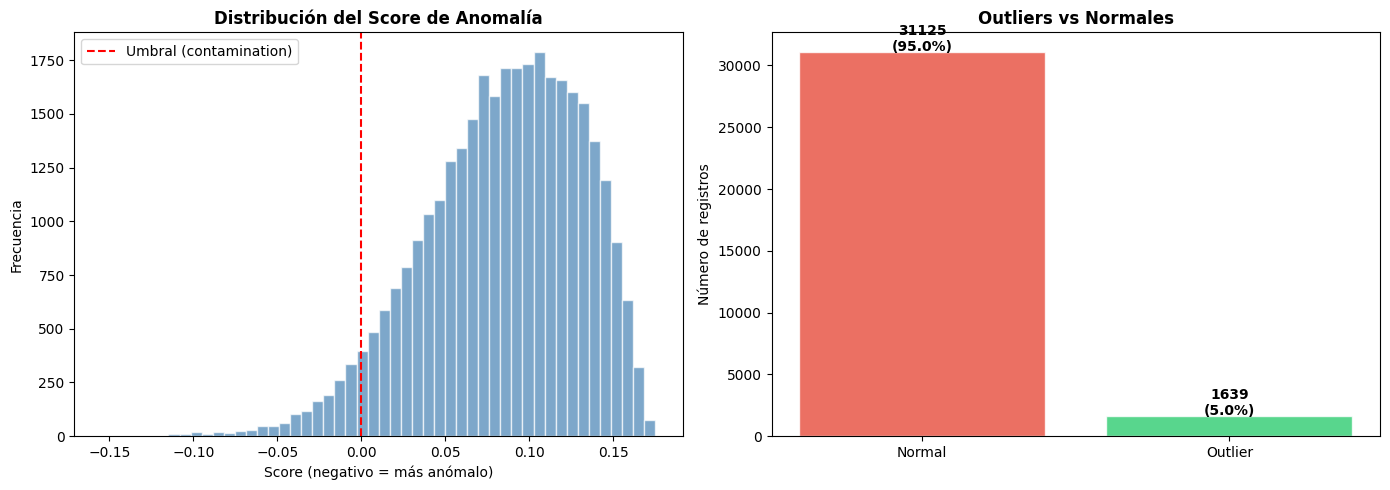

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma del score
axes[0].hist(df['outlier_score'], bins=50, color='steelblue', alpha=0.7, edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Umbral (contamination)')
axes[0].set_title('Distribución del Score de Anomalía', fontweight='bold')
axes[0].set_xlabel('Score (negativo = más anómalo)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()
# Conteo outlier vs normal
counts = df['es_outlier'].value_counts()
colors = ['#e74c3c', '#2ecc71']
axes[1].bar(counts.index, counts.values, color=colors, alpha=0.8, edgecolor='white')
axes[1].set_title('Outliers vs Normales', fontweight='bold')
axes[1].set_ylabel('Número de registros')
for i, (label, val) in enumerate(counts.items()):
    axes[1].text(i, val + 50, f'{val}\n({val/n_total*100:.1f}%)',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

#Diferencia entre Normal vs Outliers

In [10]:
print("\n📋 Perfil promedio: Outliers vs Normales")
perfil = df.groupby('es_outlier')[feature_cols].mean().round(3).T
perfil['Diferencia'] = (perfil['Outlier'] - perfil['Normal']).round(3)
perfil['Dirección'] = perfil['Diferencia'].apply(
    lambda x: '📈 Mayor en outlier' if x > 0 else '📉 Menor en outlier'
)
print(perfil)


📋 Perfil promedio: Outliers vs Normales
es_outlier      Normal  Outlier  Diferencia           Dirección
PERCEPHO         1.929    3.307       1.378  📈 Mayor en outlier
P103             4.738    3.639      -1.099  📉 Menor en outlier
P104             3.211    4.556       1.345  📈 Mayor en outlier
P105A            2.521    3.324       0.803  📈 Mayor en outlier
EDUCACION_JEFE   5.497    6.541       1.044  📈 Mayor en outlier
DOMINIO          4.866    4.818      -0.048  📉 Menor en outlier
NUM_SERVICIOS    8.000    8.000       0.000  📉 Menor en outlier
NUM_EQUIPOS      6.000    6.000       0.000  📉 Menor en outlier
NUM_OCUPADOS     1.610    2.720       1.110  📈 Mayor en outlier
EDAD_JEFE       54.245   54.054      -0.191  📉 Menor en outlier
PCT_NINOS        0.119    0.216       0.097  📈 Mayor en outlier
HACINAMIENTO     2.826    5.222       2.396  📈 Mayor en outlier


In [11]:
mm = MinMaxScaler()

# P103, P104, P105A son binarias (1=tiene, 0=no tiene)
# Las invertimos: no tener servicio = más precario
df['p103_inv'] = 1 - df['P103']   # sin agua potable
df['p104_inv'] = 1 - df['P104']   # sin desagüe
df['p105a_inv'] = 1 - df['P105A'] # sin electricidad

# HACINAMIENTO: ya va en dirección correcta (más = peor)
df['hacinamiento_norm'] = mm.fit_transform(df[['HACINAMIENTO']])

# NUM_SERVICIOS y NUM_EQUIPOS: más = mejor, los invertimos
df['servicios_inv'] = 1 - mm.fit_transform(df[['NUM_SERVICIOS']])
df['equipos_inv']   = 1 - mm.fit_transform(df[['NUM_EQUIPOS']])

# Índice final: promedio de todos los componentes
# Rango [0,1]: 0 = ninguna precariedad, 1 = precariedad máxima
df['indice_precariedad'] = (
    df['p103_inv'] +
    df['p104_inv'] +
    df['p105a_inv'] +
    df['hacinamiento_norm'] +
    df['servicios_inv'] +
    df['equipos_inv']
) / 6

print("📊 Índice de precariedad:")
print(df['indice_precariedad'].describe().round(3))

📊 Índice de precariedad:
count    32764.000
mean        -0.891
std          0.368
min         -2.615
25%         -1.126
50%         -0.826
75%         -0.647
max          0.374
Name: indice_precariedad, dtype: float64


N° 

In [15]:
# Umbrales basados en percentiles
p75_ingreso      = df['PERCEPHO'].quantile(0.75)
p25_ingreso      = df['PERCEPHO'].quantile(0.25)
p75_precariedad  = df['indice_precariedad'].quantile(0.75)
p25_precariedad  = df['indice_precariedad'].quantile(0.25)

print(f"💰 PERCEPHO        — P25: {p25_ingreso:.0f}  | P75: {p75_ingreso:.0f}")
print(f"🏚️  Precariedad     — P25: {p25_precariedad:.3f} | P75: {p75_precariedad:.3f}")

# Tipo 1: gana bien pero vive mal
mascara_t1 = (
    (df['PERCEPHO'] >= p75_ingreso) &
    (df['indice_precariedad'] >= p75_precariedad)
)

# Tipo 2: gana poco pero vive bien
mascara_t2 = (
    (df['PERCEPHO'] <= p25_ingreso) &
    (df['indice_precariedad'] <= p25_precariedad)
)

df['outlier_paradojico'] = 'Normal'
df.loc[mascara_t1, 'outlier_paradojico'] = 'Ingreso alto + Precariedad alta'
df.loc[mascara_t2, 'outlier_paradojico'] = 'Ingreso bajo + Vida digna'

print("\n📋 Distribución:")
print(df['outlier_paradojico'].value_counts())

💰 PERCEPHO        — P25: 1  | P75: 2
🏚️  Precariedad     — P25: -1.126 | P75: -0.647

📋 Distribución:
outlier_paradojico
Normal                             24226
Ingreso alto + Precariedad alta     5592
Ingreso bajo + Vida digna           2946
Name: count, dtype: int64


In [16]:
vars_perfil = [
    'PERCEPHO', 'indice_precariedad',
    'HACINAMIENTO', 'P103', 'P104', 'P105A',
    'NUM_SERVICIOS', 'NUM_EQUIPOS', 'POBREZA'
]

print("\n📋 Perfil promedio por tipo:")
print(
    df.groupby('outlier_paradojico')[vars_perfil]
    .mean().round(3)
)


📋 Perfil promedio por tipo:
                                 PERCEPHO  indice_precariedad  HACINAMIENTO  \
outlier_paradojico                                                            
Ingreso alto + Precariedad alta     2.399              -0.488         3.469   
Ingreso bajo + Vida digna           0.997              -1.349         1.925   
Normal                              2.027              -0.928         2.949   

                                  P103   P104  P105A  NUM_SERVICIOS  \
outlier_paradojico                                                    
Ingreso alto + Precariedad alta  3.737  2.626  1.774            8.0   
Ingreso bajo + Vida digna        5.125  3.375  4.704            8.0   
Normal                           4.848  3.417  2.482            8.0   

                                 NUM_EQUIPOS  POBREZA  
outlier_paradojico                                     
Ingreso alto + Precariedad alta          6.0    2.816  
Ingreso bajo + Vida digna                6.0    2.8